In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from code.io import read_data, filter_data
from code.const import TRIGGER_TIME
from code.analysis import Analyzer

from code.functions import *
from code.prior import *
from code.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

from code.utils import unit_conversion
from code.sed import *

## 7DT SED fit

In [66]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)
x0 = pivot_finder(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], df_sdt["flux_error_mJy"])
print(x0/1e14)

5.903434426266961


In [67]:

eta = host_galaxy_extinction_curve(df_sdt["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=6e14) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt["flux_error_mJy"], x_data_error=df_sdt["frequency_error_Hz"], param_bounds=param_bounds, prior=prior)
alz_sed.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+01   [-52.1698..-52.1696]*| it/evals=4313/106834 eff=4.0485% N=300      0 0     
[ultranest] Likelihood function evaluations: 107099
[ultranest]   logZ = -61.95 +- 0.1021
[ultranest] Effective samples strategy satisfied (ESS = 1192.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.10, need <0.5)
[ultranest]   logZ error budget: single: 0.17 bs:0.10 tail:0.01 total:0.10 required:<0.50
[ultranest] done iterating.


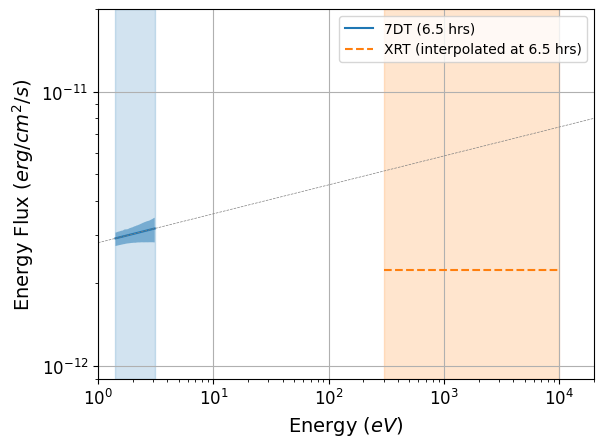

In [74]:

ax = plt.gca()
min_nu = unit_conversion(4000, "AA", "Hz")
max_nu = unit_conversion(8750, "AA", "Hz")
nu_grid = np.geomspace(min_nu, max_nu, 100)

plot_sed(nu_grid, power_law(nu_grid, *alz_sed.best_fit_params[:2], x0=1e15), ax=ax, y_unit="sed", x_unit="eV", label="7DT (6.5 hrs)")
plot_sed_from_samples(nu_grid, alz_sed.results['samples'], ax=ax, y_unit="sed", x_unit="eV")

extrapolate_range = np.geomspace(unit_conversion(1, "eV", "Hz"), unit_conversion(200, "keV", "Hz"), 100)
plot_sed(extrapolate_range, power_law(extrapolate_range, *alz_sed.best_fit_params[:2], x0=1e15), ax=ax, y_unit="sed", x_unit="eV", color="gray", ls="--", lw=0.5)

ax.set_xlim(1, 20000)
ax.set_ylim(9e-13, 2e-11)

ax.axvspan(unit_conversion(min_nu, "Hz", "eV"), unit_conversion(max_nu, "Hz", "eV"), color="C0", alpha=0.2)
ax.axvspan(300, 10000, color="C1", alpha=0.2)

ax.plot([300, 10000], [alz_xrt.model(6.5), alz_xrt.model(6.5)], color="C1", ls="--", label="XRT (interpolated at 6.5 hrs)")
ax.legend()
ax.grid()

In [69]:
df_xrt = read_data("xrt")
df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["Flux_high"], df_filtered["Flux_low"])])
alz_xrt = Analyzer(df_filtered["Time"]/3600, df_filtered["Flux"], power_law, y_data_error=y_err)
alz_xrt.run(method="curve_fit")

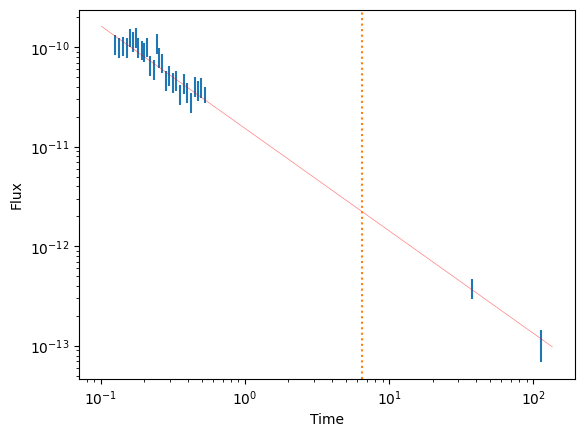

In [70]:
alz_xrt.plot_data(label="XRT")
ax = alz_xrt.plot_model(color="red", lw=0.5, alpha=0.5)

ax.axvline(6.5, color="C1", ls=":", label="XRT (predicted at 6.5 hrs)")
